# AI Wildlife Detection

The objective of this project is to create a classification model for wildlife (animals) in farms or houses in rural areas. Wild animals can be dangerous if they catch you by surprise, so the model created in this notebook aims to serve as a tool for our higher-level application to emit alerts when the model detects them in frame.

In [1]:
import requests
import zipfile
import json
import os
import random
from concurrent.futures import ThreadPoolExecutor, as_completed # parallel
import matplotlib.pyplot as plt
import numpy as np
import copy # to deep copy models
from collections import Counter, defaultdict

# pytorch
import torch
import torchvision.models as tv_models # pre-trained models
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torch.nn as nn

# evaluation
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# progress bar
from tqdm import tqdm
from tqdm.auto import tqdm

# image processing
from PIL import Image, ImageFile

# onnx
import onnxruntime as ort
import torch.onnx

## Exploratory Data Analysis

To kick it off, let's do some EDA after downloading the (extensive) dataset. We will be using the [Oregon Critters](https://lila.science/datasets/oregon-critters/) dataset. It has data gathered by the U.S. Forest Service, containing 99,909 images from camera traps in Oregon, USA, according to their site. It contains 46 classes (including the `empty` class).

First, let's download the dataset directly from the Oregon Critters source. Its metadata comes in a zip, including annotations (labels, image ids, etc).

In [2]:
url = "https://lilawildlife.blob.core.windows.net/lila-wildlife/oregon-critters/oregon_critters.zip"

with requests.get(url, stream=True) as r:
    with open("oregon.zip", "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

Let's verify our previous claim by printing out the contents of the zip file.

In [3]:
zf = zipfile.ZipFile("oregon.zip")
zf.namelist()

['oregon_critters.json']

Once we know the metadata is in there (and it's of json nature), we can open the zip file (safely), and load the data as json.

In [4]:
with zipfile.ZipFile("oregon.zip", "r") as zf:
    with zf.open("oregon_critters.json") as f:
        data = json.load(f)

type(data)

dict

Since the metadata is a `dict`, we can print its keys to see what's in the file. Particularily, we care about `images`, `annotations` and `categories`. 

In [5]:
print(data.keys())

dict_keys(['info', 'images', 'annotations', 'categories'])


Let's understand the size of the data a little further.

In [6]:
print("Images:", len(data["images"]))
print("Annotations:", len(data["annotations"]))
print("Categories:", len(data["categories"]))

Images: 99909
Annotations: 102014
Categories: 46


We can see there are ~100,000 images, each with their annotation, constrained to 46 categories.

Let's print these categories to perform data selection. The dataset is too big for a project of this size and our available compute, so we can initially reduce it by only including labels that are relevant to our location (Baja California). To do this, let's first map each category ID to its string label.

In [7]:
cat_ids = {c["id"]: c["name"] for c in data["categories"]}
print("Categories:")
for cat_id, cat_name in cat_ids.items():
    print(f"{cat_id}: {cat_name}")

Categories:
0: empty
1: coyote
2: bat species
3: strigidae family
4: ruffed grouse
5: red fox
6: canada jay
7: pileated woodpecker
8: reptile or amphibian
9: bobcat
10: marten
11: california ground squirrel
12: mink
13: western spotted skunk
14: mountain beaver
15: black bear
16: black-tailed deer
17: cougar
18: roosevelt elk
19: stellers jay
20: catharus species
21: varied thrush
22: dark-eyed junco
23: american robin
24: leporidae family
25: douglas squirrel
26: humboldt's flying squirrel
27: townsend's chipmunk
28: weasel family
29: parulidae family
30: invertebrate
31: picidae family
32: neotoma species
33: poecile species
34: virginia opossum
35: troglodytidae family
36: mountain quail
37: northern raccoon
38: striped skunk
39: western gray squirrel
40: northern flicker
41: domestic dog
42: human
43: small mammal
44: gray fox
45: other bird


Particularily, we chose the following labels to include in our classification model. Our criterion for selection was googling which animals are present in Baja California at the time of this notebook being created.

| id  | label |
|-----|--------
| 0   | empty (control) |
| 1   | coyote |
| 8   | reptile or amphibian |
| 11  | california ground squirrel |
| 13  | western spotted skunk |
| 23  | american robin |
| 24  | leporidae family |
| 30  | invertebrate |
| 37  | northern raccoon |
| 38  | striped skunk |
| 41  | domestic dog |
| 42  | human |
| 43  | small mammal |
| 44  | gray fox |
| 45  | other bird |

In [8]:
target_class_ids = {
    0, # empty
    1, 8, 11, 13, 23, 24, 30, 37, 38, 41, 42, 43, 44, 45
}

Using these target classes, we can first filter out the annotations only relevant to us. After manually observing the metadata JSON, images are mapped to their label in `annotations` by including `image_id`, which maps an image "id" to its path in the same-level `images` object.

Let's filter out annotations whose `category_id` are in our target classes.

In [9]:
filtered_annotations = [
    ann for ann in data["annotations"] if ann["category_id"] in target_class_ids
]

print("Annotations:", len(filtered_annotations))

Annotations: 28001


Now let's get the `image_id`s so in a further step we can get the images themselves from the other JSON object.

In [10]:
image_ids = {ann["image_id"] for ann in filtered_annotations}

print("Images:", len(image_ids))

Images: 27646


We've got the `image_id`s, so we can do the same filtering process in the `images` object to filter only images whose annotations we kept.

In [11]:
filtered_images = [
    img for img in data["images"]
    if img["id"] in image_ids
]

print("Images kept:", len(filtered_images))

Images kept: 27646


We've already got `target_class_ids`, but for sake of consistency let's also get the filtered categories of this images to construct our pseudo-dataset prior to data loading.

In [12]:
filtered_categories = [
    cat for cat in data["categories"]
    if cat["id"] in target_class_ids
]

In [13]:
subset_data = {
    "images": filtered_images,
    "annotations": filtered_annotations,
    "categories": filtered_categories
}

Let's save this pseudo-dataset for future use:

In [14]:
with open("oregon_filtered.json", "w") as f:
    json.dump(subset_data, f)

Now, images weren't downloaded with our metadata files, only their annotations (labels, image ids, etc), categories and their image path. Their image path can be used to directly download the image without downloading the entire set, this is how we save bandwith and execution time (we haven't even gotten to the training step yet).

This is all according to the [Oregon Critters](https://lila.science/datasets/oregon-critters/) site. 

Let's look at the structure of one entry first.

In [15]:
print(filtered_images[0])

{'location': 'COA_NA', 'datetime': '2019-08-15 14:11:33', 'split': 'train', 'width': 3840, 'height': 2880, 'file_name': 'COA_2019/COA_2019_empty/images/10022-1__2019-08-15__14-11-33(1).JPG', 'id': 'COA_2019/COA_2019_empty/images/10022-1__2019-08-15__14-11-33(1).JPG', 'sequence_level_annotation': False}


### Downloading the dataset

Let's first make the containing folder for our images.

In [16]:
base_url = "https://lilawildlife.blob.core.windows.net/lila-wildlife/oregon-critters/"
out_dir = "images_subset"
os.makedirs(out_dir, exist_ok=True)

Then create our download function that will be ran per image. We added an `ok`, `skip`, `fail` mechanic to avoid redownloading the dataset each time the notebook is ran.

In [17]:
session = requests.Session()

def download_one(img):
    url = base_url + img["file_name"]
    path = os.path.join(out_dir, img["file_name"])
    tmp_path = path + ".part" # images are downloaded in parts (corrupted files)

    if os.path.exists(path): # if it exists, we return a success (True), the path, and the state
        return True, img["file_name"], "skipped"

    # if it doesn't exist, let's create it's containing path within our dataset directory
    os.makedirs(os.path.dirname(path), exist_ok=True)

    # then download the image (in a stream, to avoid memory problems)
    try:
        r = session.get(url, timeout=20, stream=True)
        r.raise_for_status() # this checks status 

        # then we check the download and write its parts into one single file
        with open(tmp_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

        # and return success after replacing the part file with the complete one
        os.replace(tmp_path, path)
        return True, img["file_name"], None

    except Exception as e:
        # otherwise, if there was an error downloading (which there was, like 200 times) we can return 
        # fail (False), the path, and the error message
        if os.path.exists(tmp_path):
            os.remove(tmp_path)
        return False, img["file_name"], str(e)

After we have our download function, let's get the paths of the images we filtered that currently do **NOT** exist.

In [18]:
to_download = [
    img for img in filtered_images
    if not os.path.exists(os.path.join(out_dir, img["file_name"])) # ONLY download if the file doesn't exist
]

Finally, let's download the files. We use a `ThreadPoolExecutor`, according to Google, so we can download the images in parallel. 

In [19]:
results_ok = 0
results_fail = 0
results_skip = len(filtered_images) - len(to_download)

with ThreadPoolExecutor(max_workers=16) as ex: # parallel downloading
    futures = [ex.submit(download_one, img) for img in to_download] # submit the task to the thread

    # tqdm is a progress bar library, we can use it to show the progress of our downloads
    # we saw it in class in the teacher's notebook
    with tqdm(total=len(filtered_images), desc="Downloading", unit="img") as pbar:
        pbar.update(results_skip)
        pbar.set_postfix(ok=results_ok, fail=results_fail, skip=results_skip)

        for fut in as_completed(futures):
            ok, name, err = fut.result()
            if ok:
                results_ok += 1 # if it was ok, we count it as a success
            else:
                results_fail += 1 # if it was not ok, we count it as a failure

            pbar.set_postfix(ok=results_ok, fail=results_fail, skip=results_skip)
            pbar.update(1)

print("Done:", results_ok, "ok,", results_fail, "failed,", results_skip, "skipped")

Downloading:   0%|          | 0/27646 [00:00<?, ?img/s]

Done: 0 ok, 275 failed, 27371 skipped


### Missing Values

Since we had some images fail (275), we can safely remove them from our dataset

Once again, let's get images that exist on disk right now. Same code as bove except this is after everything has been downloaded.

In [20]:
valid_images = [
    img for img in filtered_images
    if os.path.exists(os.path.join(out_dir, img["file_name"]))
]

valid_ids = {img["id"] for img in valid_images}

valid_annotations = [
    ann for ann in filtered_annotations
    if ann["image_id"] in valid_ids
]

In [21]:
print("Before:")
print("Images: ", len(filtered_images))
print("Annotations: ", len(filtered_annotations))

print("\nAfter:")
print("Images: ", len(valid_images))
print("Annotations: ", len(valid_annotations))

Before:
Images:  27646
Annotations:  28001

After:
Images:  27371
Annotations:  27639


Then, we can safely remove them from our dataset. Remember we created `oregon_filtered.json` to be reused later. We can overwrite that file as it will be read from by our data loader.

In [22]:
subset_data_clean = {
    "images": valid_images,
    "annotations": valid_annotations,
    "categories": filtered_categories,
}

with open("oregon_filtered.json", "w") as f:
    json.dump(subset_data_clean, f)

# let's not forget to update our references
filtered_images[:] = valid_images
filtered_annotations[:] = valid_annotations

### Image sizes

We saw in class that a very common transformation in the preprocessing pipeline is `Resize`. Let's see if it's needed.

In [23]:
# take random 1000 images
sample_images = random.sample(filtered_images, min(1000, len(filtered_images)))

# code to get unique dimensiones with help of VSCode autocomplete
unique_dims = set() # sets can't have repeated items

# we iterate over all our images
for img in sample_images:
    path = os.path.join(out_dir, img["file_name"])

    if os.path.exists(path): # only if it exists
        try:
            with Image.open(path) as im:
                unique_dims.add(im.size)  # we add their (width, height)
        except Exception:
            pass

# print distinct (unique) dimensions
for w, h in sorted(unique_dims):
    print(f"{w} x {h}")

1920 x 1080
1920 x 1440
2048 x 1152
2048 x 1440
2048 x 1536
3264 x 2448
3776 x 2124
3840 x 2160
3840 x 2880
4000 x 3000
4416 x 3312
5280 x 3960


In [24]:
print("Total distinct sizes:", len(unique_dims))

Total distinct sizes: 12


As we can see, there is more than one size (width, height) for images. This means that we will have to resize them to match the same dimension so it can enter our pipeline.

Additionally, after a couple of trial and error trobuleshooting, these images are in very high resolution, **if we resize them, this will make our model training CONSIDERABLY FASTER**. 

Ergo, it is safe to assume we use `Resize`

And finally, let's get three random images and print them to see what else we can add.

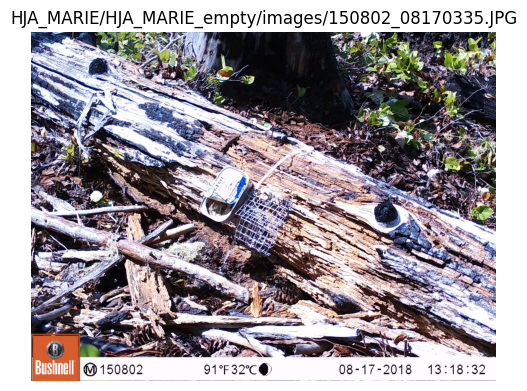

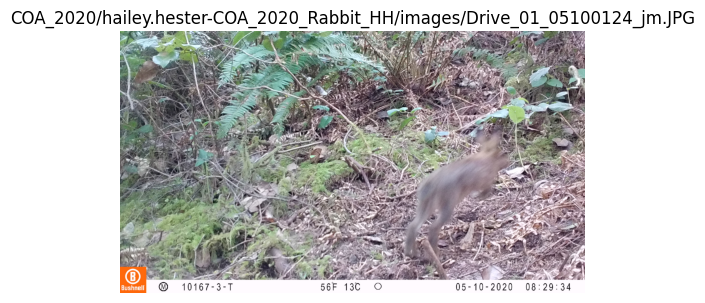

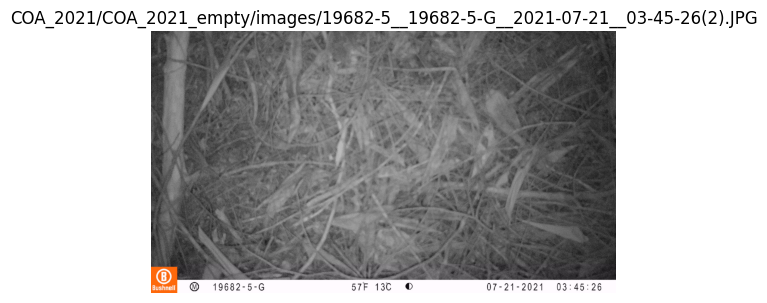

In [25]:
sample_images = random.sample(filtered_images, min(3, len(filtered_images)))

for img in sample_images:
    path = os.path.join(out_dir, img["file_name"])

    if os.path.exists(path):
        try:
            im = Image.open(path)
            plt.figure(figsize=(6, 6))
            plt.imshow(im)
            plt.title(img["file_name"])
            plt.axis("off")
            plt.show()
        except Exception as e:
            print(f"Error loading {img['file_name']}: {e}")
    else:
        print(f"Missing: {img['file_name']}")

We can see there is a footer, which we believe is important to be removed as our production images will *not* have a footer.

Additionally, we need to add some color variance before we convert to Grayscale, because some of our images are already in Grayscale, which may yield inconsistent results with same-class entries.

## Preprocessing

And, here is our preprocessing pipeline and why we chose each transformation:
- Crop lambda: Remove the bottom 6% of the image to get rid of the footer we mentioned.
- Resize: Our __first__ model will need a 320x320 entry. 
- Random crop: Data augmentation
- Color jitter: Data augmentation
- Random grayscale: Uniformity
- ToTensor: Pytorch works with tensors
- Normalize: ImageNet only works in these values

In [26]:
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.crop((0, 0, img.width, int(img.height * 0.94)))), # remove footer
    transforms.Resize(320),
    transforms.RandomCrop(288),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.crop((0, 0, img.width, int(img.height * 0.94)))), # remove footer
    transforms.Resize(320),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

We created a transform pipeline for `train` and `validation` because most of the transform made in `train` would cause inadequate results in newly-seen data (validation). Particularily, our research showed (after multiple failed models) that if we introduced random cropping, jitter and grayscale on our validation and test set, the model would perform worse because it could skew the results since, at the end of the day, it is classifying an image different to the input.  

Let's view these transformations in action:

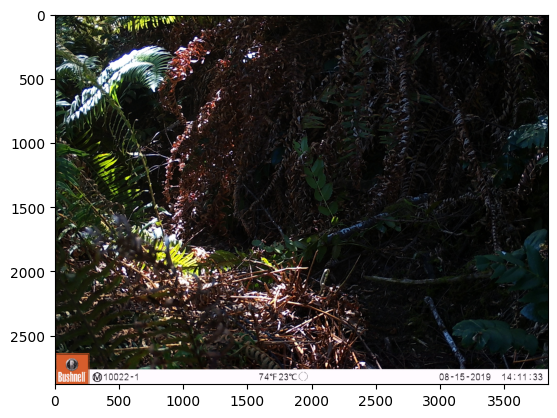

In [27]:
img0 = Image.open(os.path.join(out_dir, filtered_images[0]["file_name"]))
plt.imshow(img0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.1171243].


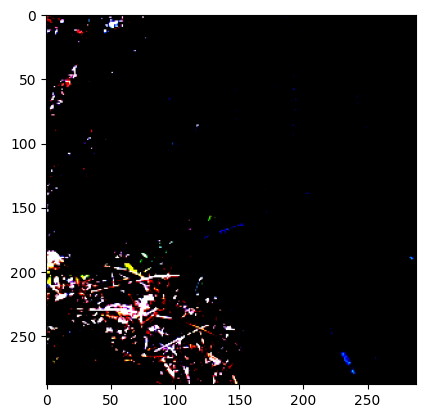

In [28]:
img = train_transform(img0)
plt.imshow(img.permute(1, 2, 0))

## Data Loading

After our preprocessing pipeline is in place, we can create our dataset. We will need to repeat this step two more times since we are training on 3 different architectures, using 3 different pre-trained models, which take 3 different input properties.

First, let's construct a map of images to their label (category) and a map of category IDs to their index in the target classes.

In [29]:
img_to_label = {}
for ann in valid_annotations:
    img_id = ann["image_id"]
    if img_id not in img_to_label:
        img_to_label[img_id] = ann["category_id"]

sorted_cat_ids = sorted(target_class_ids)
cat_to_idx = {cat_id: idx for idx, cat_id in enumerate(sorted_cat_ids)}
num_classes = len(sorted_cat_ids)
print(f"num_classes: {num_classes}")
print("cat_to_idx:", cat_to_idx)

num_classes: 15
cat_to_idx: {0: 0, 1: 1, 8: 2, 11: 3, 13: 4, 23: 5, 24: 6, 30: 7, 37: 8, 38: 9, 41: 10, 42: 11, 43: 12, 44: 13, 45: 14}


We also run into a problem where some classes do not have enough presence in our dataset, let's drop them .

In [30]:
present_class_ids = set(img_to_label.values())
dropped = target_class_ids - present_class_ids
target_class_ids = {c for c in target_class_ids if c in present_class_ids}
img_to_label = {k: v for k, v in img_to_label.items() if v in target_class_ids}
sorted_cat_ids = sorted(target_class_ids)
cat_to_idx = {cat_id: idx for idx, cat_id in enumerate(sorted_cat_ids)}
num_classes = len(sorted_cat_ids)
print(f"Dropped classes: {dropped}")
print(f"Remaining: {num_classes}")

Dropped classes: {42}
Remaining: 14


Then we can create a pytorch `Dataset`, which takes the images, the map of images to their label, the labels to their index in the map, and the source directory.

In [31]:
class OregonDataset(Dataset):
    def __init__(self, images, img_to_label, cat_to_idx, images_dir, transform=None):
        # a sample is a tuple of (image filename, label index)
        self.samples = [
            (img["file_name"], cat_to_idx[img_to_label[img["id"]]])
            for img in images if img["id"] in img_to_label
        ] 
        self.images_dir = images_dir
        self.transform  = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # when we get an item, we load the RGB image and apply the transform (if any)
        # * before returning it with its label
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.images_dir, fname)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

Some images were partially downloaded. According to StackOverflow, this is the fix:

In [32]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

Then, we can create the data loaders, using a batch size of `64`.

For now, we will only take 15% of the loaded dataset because there are tens of thousands of entries, which we don't have the compute for.

In [33]:
batch_size = 64
subset_percent = 0.15

First, we can extract the 15% of our subset.

In [34]:
ds_train = OregonDataset(valid_images, img_to_label, cat_to_idx, out_dir, transform=train_transform)
ds_eval  = OregonDataset(valid_images, img_to_label, cat_to_idx, out_dir, transform=val_transform)

labels_all = [s[1] for s in ds_train.samples] # labels
all_indices = list(range(len(ds_train))) # indices

# stratify the dataset, we only want the first `subset_percent` of the dataset, the remaining 90% is discarded.
subset_indices, _ = train_test_split(
    all_indices,
    train_size=subset_percent,
    stratify=labels_all,
    random_state=42
)

# from all labels in the subset, filter out our 10%
subset_labels = [labels_all[i] for i in subset_indices]

We've already removed classes with poor presence in the dataset. From there, we can guarantee that they're going to be present in EVERY set by putting a minimum of classes in the parent dataset before stratification. We will hold 100 minimum per label.

In [35]:
# generated with AI
min_per_classes = 100
held_out_by_class = defaultdict(list) 

for i in set(all_indices) - set(subset_indices):
    held_out_by_class[labels_all[i]].append(i)

extra = []
for cls, cnt in Counter(subset_labels).items():
    if cnt < min_per_classes:
        extra += held_out_by_class[cls][:min_per_classes - cnt]

subset_indices = list(subset_indices) + extra
subset_labels  = [labels_all[i] for i in subset_indices]

Then, we can do our usual `train_test_split` (with stratification) for an 80-10-10.

In [36]:
train_idx, temp_idx = train_test_split(subset_indices, test_size=0.2, stratify=subset_labels, random_state=42)
temp_labels = [labels_all[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_labels, random_state=42)

train_set = Subset(ds_train, train_idx)
val_set = Subset(ds_eval,  val_idx)
test_set = Subset(ds_eval,  test_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print(f"Original dataset: {len(ds_train)}")
print(f"Train: {len(train_set)}")
print(f"Val: {len(val_set)}")
print(f"Test: {len(test_set)}")

Original dataset: 27371
Train: 3642
Val: 455
Test: 456


Let's ensure class presence in every class

In [37]:
# generated with AI
idx_to_cat = {v: k for k, v in cat_to_idx.items()}
split_labels = {
    "train": [labels_all[i] for i in train_idx],
    "val":   [labels_all[i] for i in val_idx],
    "test":  [labels_all[i] for i in test_idx],
}
counts = {split: Counter(ls) for split, ls in split_labels.items()}
print(f"{'class':<6} {'train':>6} {'val':>6} {'test':>6}")
print("-" * 27)
for cls_idx in sorted(cat_to_idx.values()):
    row = [counts[s].get(cls_idx, 0) for s in ("train", "val", "test")]
    print(f"{idx_to_cat[cls_idx]:<6} {row[0]:>6} {row[1]:>6} {row[2]:>6}")

class   train    val   test
---------------------------
0        1063    133    133
1          60      8      7
8          80     10     10
11         80     10     10
13        270     34     34
23        190     23     24
24        738     92     93
30         80     10     10
37         80     10     10
38         80     10     10
41         80     10     10
43        630     79     79
44         80     10     10
45        131     16     16


## Training

For training, we will be reusing our training functions created in a different notebook.

In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

`get_batch_accuracy` gets the accuracy of all batches.

In [39]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

`train` follows the usual training steps for batches we have followed in class. We added the following modifications:
- Using `tqdm` to track each epoch (instead of just the training time) since we were seeing models go frozen if we increased the number of workers (on Windows)
- Return the loss and accuracy metrics per epoch
- Add early stopping

In [40]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None, patience=3):
    res = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    total_batches = len(_train_loader) + len(_val_loader)
    best_val_loss = float('inf')
    best_weights = None
    no_improve = 0

    overall_pbar = tqdm(total=_num_epochs, desc="Training", unit="epoch", leave=True)
    tqdm.write("")

    for epoch in range(_num_epochs):
        _model.train()
        train_loss = 0.0
        train_acc = 0.0

        with tqdm(total=total_batches, desc=f"Epoch {epoch+1}/{_num_epochs}", unit="batch", leave=True) as pbar:
            for X_batch, y_batch in _train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                _optimizer.zero_grad()
                _x = X_batch
                if _transforms is not None:
                    _x = _transforms(_x)
                outputs = _model(_x)
                loss = _criterion(outputs, y_batch)
                loss.backward()
                _optimizer.step()
                train_loss += loss.item() * X_batch.size(0)
                train_acc  += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))
                pbar.update(1)

            epoch_train_loss = train_loss / len(_train_loader.dataset)

            _model.eval()
            val_loss = 0.0
            val_acc  = 0.0
            with torch.no_grad():
                for X_val, y_val in _val_loader:
                    X_val, y_val = X_val.to(device), y_val.to(device)
                    val_outputs = _model(X_val)
                    val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                    val_acc  += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))
                    pbar.update(1)

            epoch_val_loss = val_loss / len(_val_loader.dataset)
            pbar.set_postfix(
                train_loss=f"{epoch_train_loss:.4f}",
                train_acc=f"{train_acc:.4f}",
                val_loss=f"{epoch_val_loss:.4f}",
                val_acc=f"{val_acc:.4f}"
            )

        overall_pbar.update(1)
        overall_pbar.set_postfix(train_loss=f"{epoch_train_loss:.4f}", val_acc=f"{val_acc:.4f}")

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_weights = copy.deepcopy(_model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                tqdm.write(f"Early stopping at epoch {epoch+1}")
                overall_pbar.close()
                break

    overall_pbar.close()

    if best_weights is not None:
        _model.load_state_dict(best_weights)

    tqdm.write(f"Final: train_loss: {res['train_loss'][-1]:.4f}  train_acc: {res['train_acc'][-1]:.4f}  val_loss: {res['val_loss'][-1]:.4f}  val_acc: {res['val_acc'][-1]:.4f}")

    return res

`plot_learning_curves` simply takes in the output of `train` and plots the learning curves.

In [41]:
def plot_learning_curves(res, title):
    epochs = range(1, len(res['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, res['train_loss'], label='Train')
    ax1.plot(epochs, res['val_loss'],   label='Validation')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, res['train_acc'], label='Train')
    ax2.plot(epochs, res['val_acc'],   label='Validation')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

`measure_overfitting` is a new function we added to get the delta between validation and train metrics. If the delta passes a threshold for either metric, then we consider it overfitting.

- Loss overfitting: `> 0.5`
- Accuracy overfitting: `> 0.1`

In [42]:
def measure_overfitting(res):
    loss_gap = res['val_loss'][-1] - res['train_loss'][-1]
    acc_gap  = res['train_acc'][-1] - res['val_acc'][-1]
    print(f"Loss delta (val-train): {loss_gap:.4f}")
    print(f"Accuracy delta (train-val): {acc_gap:.4f}")

    overfitting = acc_gap > 0.1 or loss_gap > 0.5
    if overfitting:
        print("Overfitting")
    else:
        print("No overfitting")

    return loss_gap, acc_gap, overfitting

### Model

For this project, we will be revising three pre-models with three different approaches.

They will all be trained using transfer learning and a further fine tuning for good measure.

#### Architecture 1

The first model we use is `EfficientNet B2`, which comes bundled in `pytorch`'s `tv_models`. It is the biggest model out of the three we chose.

In [43]:
arch1 = tv_models.efficientnet_b2(weights=tv_models.EfficientNet_B2_Weights.DEFAULT)
arch1 = arch1.to(device)

In [44]:
arch1

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [45]:
total_params = sum(p.numel() for p in arch1.parameters())
print(f"Params: {total_params:,}")

Params: 9,109,994


For transfer learning, we will add a classifier head so the model can recognize our classes. This model's classifier is at `classifier[1]` as per documentation.

In [46]:
in_features = arch1.classifier[1].in_features # input from last layer
arch1.classifier[1] = nn.Linear(in_features, num_classes) # add a linear layer
arch1 = arch1.to(device)

#### Transfer Learning

In transfer learning, we will freeze all layers except the last one (which we just added).

In [47]:
for param in arch1.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in arch1.parameters() if p.requires_grad)
total = sum(p.numel() for p in arch1.parameters())
print(f"Params in the classifier head: {trainable:,} / {total:,}")

Params in the classifier head: 19,726 / 7,720,720


In transfer learning, we will use:
- `Adam` optimizer (only on the classifier)
- `CrossEntropyLoss`

In [48]:
optimizer_tl = torch.optim.Adam(arch1.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [49]:
res = train(arch1, train_loader, val_loader, criterion, optimizer_tl, _num_epochs=5)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 3/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 4/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 5/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Final: train_loss: 1.2098  train_acc: 0.6269  val_loss: 1.1085  val_acc: 0.6923


Then, we can save the model in-memory and in a `state_dict` for retrieval later.

In [50]:
res_arch1_tl = res
torch.save(arch1.state_dict(), 'arch1_tl.pth')

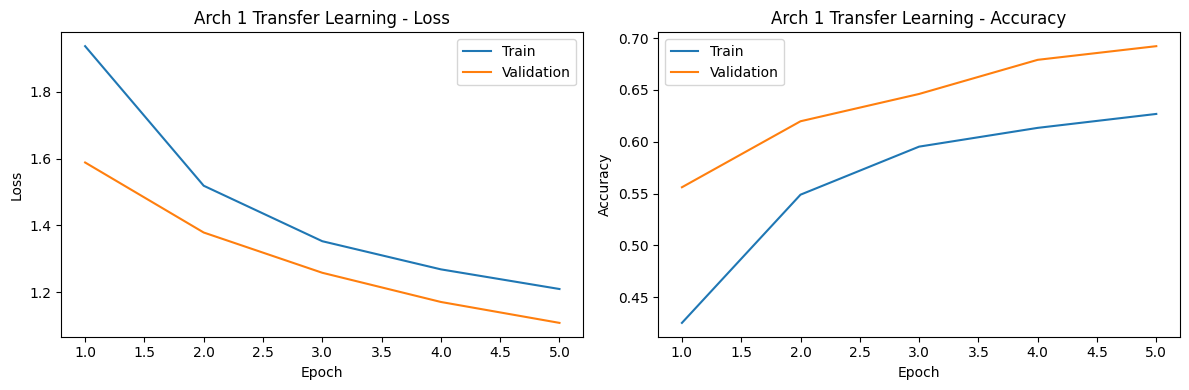

In [51]:
plot_learning_curves(res_arch1_tl, 'Arch 1 Transfer Learning')

As can be seen, the model had decent performance as its loss decreased and accuracy increased, but we can still fine tune it to get better results (presumably).

#### Fine Tuning

To fine tune, let's load the model again into the same device.

In [52]:
arch1.load_state_dict(torch.load('arch1_tl.pth', map_location=device))

<All keys matched successfully>

In [53]:
arch1

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Freeze everything again, and unfreeze the last 2 layers (of the feature layers, not the classifiers) and the classifier itself.

In [54]:
for param in arch1.parameters():
    param.requires_grad = False

unfrozen_internal = list(arch1.features.children())[-2:]
for block in unfrozen_internal:
    for param in block.parameters():
        param.requires_grad = True

for param in arch1.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in arch1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in arch1.parameters())
print(f"Trainable: {trainable:,} / {total:,}")

Trainable: 3,253,978 / 7,720,720


Then, we will use the same loss criterion (`CrossEntropyLoss`), but the optimizer will have a different learning rate for
the internal layers and the classifier head:
- Our research (and dozens of runs of this notebook) showed that we can put a smaller learning rate on the internal layers because they're already trained and they are bigger.
- But the classifier head can have higher learning rate because it's a new head that we added.

In [55]:
ft_params = [
    {"params": [p for b in unfrozen_internal for p in b.parameters()], "lr": 1e-5},
    {"params": list(arch1.classifier.parameters()), "lr": 1e-3},
]

ft_optimizer = torch.optim.Adam(ft_params)
criterion = nn.CrossEntropyLoss()

In [56]:
res_arch1_ft = train(arch1, train_loader, val_loader, criterion, ft_optimizer, _num_epochs=5)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 3/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 4/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 5/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Final: train_loss: 0.9698  train_acc: 0.6864  val_loss: 0.8892  val_acc: 0.7560


Once again, save the model.

In [57]:
torch.save(arch1.state_dict(), 'arch1_ft.pth')

And plot its curves.

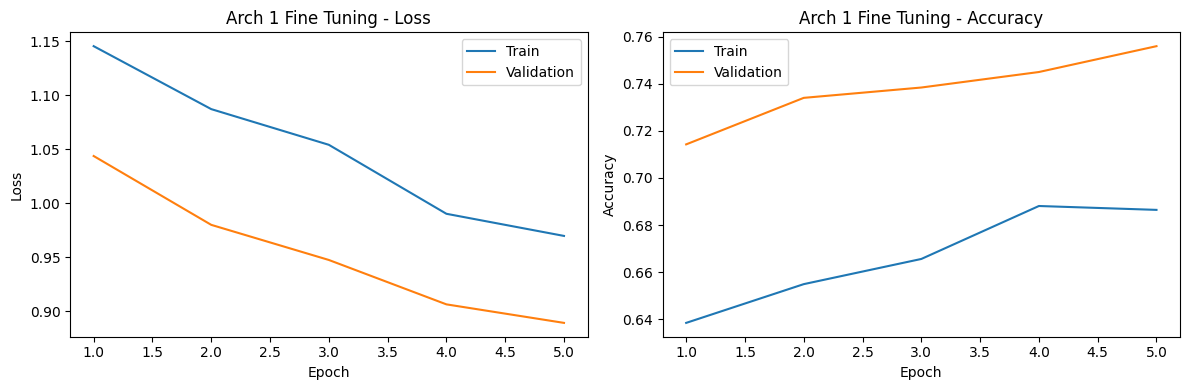

In [58]:
plot_learning_curves(res_arch1_ft, 'Arch 1 Fine Tuning')

The model's performance increased but not substantially. We will evaluate other models and compare them at the end for further examination.

### Architecture 2

This second architecture will be `MobileNet V3 Small Weights`, which also comes bundled with `pytorch`.

As we explained in the preprocessing section, we will need a different transformation pipeline for our other architectures.

_**Note: This is because other pre-trained models have different input features, like image size. Particularily, our smaller models will take lesser sized images**_.

We can just copy the old transformation pipeline and replace the parameters.

In [59]:
train_transform_160 = transforms.Compose([
    transforms.Lambda(lambda img: img.crop((0, 0, img.width, int(img.height * 0.94)))),
    transforms.Resize(192),
    transforms.RandomCrop(160),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform_160 = transforms.Compose([
    transforms.Lambda(lambda img: img.crop((0, 0, img.width, int(img.height * 0.94)))),
    transforms.Resize(192),
    transforms.CenterCrop(160),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

ds_train_160 = OregonDataset(valid_images, img_to_label, cat_to_idx, out_dir, transform=train_transform_160)
ds_eval_160  = OregonDataset(valid_images, img_to_label, cat_to_idx, out_dir, transform=val_transform_160)

train_set_160 = Subset(ds_train_160, train_idx)
val_set_160   = Subset(ds_eval_160,  val_idx)
test_set_160  = Subset(ds_eval_160,  test_idx)

train_loader_160 = DataLoader(train_set_160, batch_size=batch_size, shuffle=True)
val_loader_160   = DataLoader(val_set_160,   batch_size=batch_size, shuffle=False)
test_loader_160  = DataLoader(test_set_160,  batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_set_160)}")
print(f"Val: {len(val_set_160)}")
print(f"Test: {len(test_set_160)}")

Train: 3642
Val: 455
Test: 456


We load the model.

In [60]:
arch2 = tv_models.mobilenet_v3_small(weights=tv_models.MobileNet_V3_Small_Weights.DEFAULT)
arch2  = arch2.to(device)

In [61]:
arch2

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [62]:
total_params = sum(p.numel() for p in arch2.parameters())
print(f"Params: {total_params:,}")

Params: 2,542,856


Then replace the head, once again, with a Linear layer.

In [63]:
in_features_2 = arch2.classifier[3].in_features
arch2.classifier[3] = nn.Linear(in_features_2, num_classes)
arch2 = arch2.to(device)

#### Transfer Learning

Freeze all parameters except the head

In [64]:
for param in arch2.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in arch2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in arch2.parameters())
print(f"Trainable: {trainable:,} / {total:,}")

Trainable: 605,198 / 1,532,206


We use the same `CrossEntropyLoss` loss function, and an optimizer tailored to our new classifier head.

In [65]:
optimizer_tl_2 = torch.optim.Adam(arch2.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [66]:
res = train(arch2, train_loader_160, val_loader_160, criterion, optimizer_tl_2, _num_epochs=5)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 3/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 4/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 5/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Final: train_loss: 1.0926  train_acc: 0.6321  val_loss: 0.9761  val_acc: 0.6813


Then we save.

In [67]:
res_arch2_tl = res
torch.save(arch2.state_dict(), 'arch2_tl.pth')

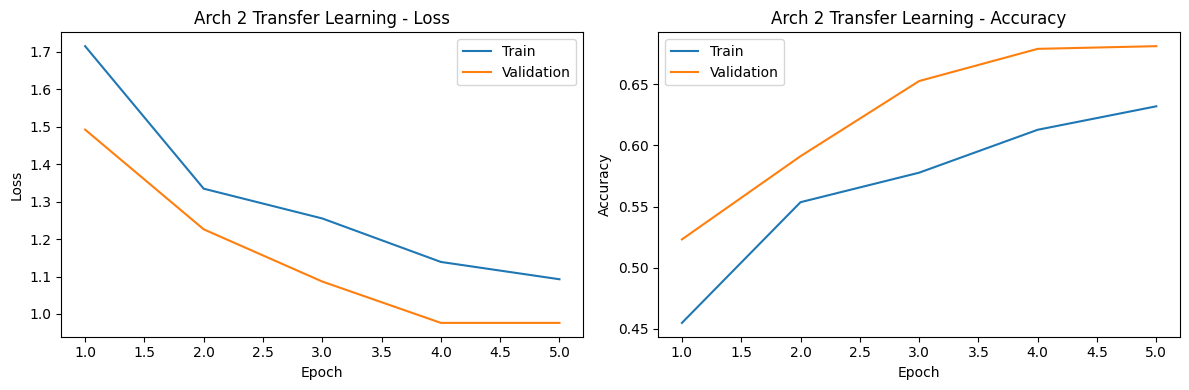

In [68]:
plot_learning_curves(res_arch2_tl, 'Arch 2 Transfer Learning')

The metrics didn't vary much. In fact, they're very similar to the first model despite them varying in size substantially. The first model is still better.

#### Fine Tuning

We can do fine tuning again. Load the model first.

In [69]:
arch2.load_state_dict(torch.load('arch2_tl.pth', map_location=device))

<All keys matched successfully>

In [70]:
arch2

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

Then freeze everything except for the last feature layer and the classifier we added.

In [71]:
for param in arch2.parameters():
    param.requires_grad = False

for param in arch2.features[-1].parameters():
    param.requires_grad = True
for param in arch2.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in arch2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in arch2.parameters())
print(f"Trainable: {trainable:,} / {total:,}  (last feature block + classifier)")

Trainable: 661,646 / 1,532,206  (last feature block + classifier)


Onec again, we choose `Adam`. Except, the model is much lighter so we can train every unfrozen layer with the same learning rate.

In [72]:
optimizer_ft_2 = torch.optim.Adam(filter(lambda p: p.requires_grad, arch2.parameters()), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [73]:
res_arch2_ft = train(arch2, train_loader_160, val_loader_160, criterion, optimizer_ft_2, _num_epochs=5)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 3/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 4/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 5/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Final: train_loss: 0.9982  train_acc: 0.6601  val_loss: 0.9265  val_acc: 0.6967


Then we save.

In [74]:
torch.save(arch2.state_dict(), 'arch2_ft.pth')

And plot.

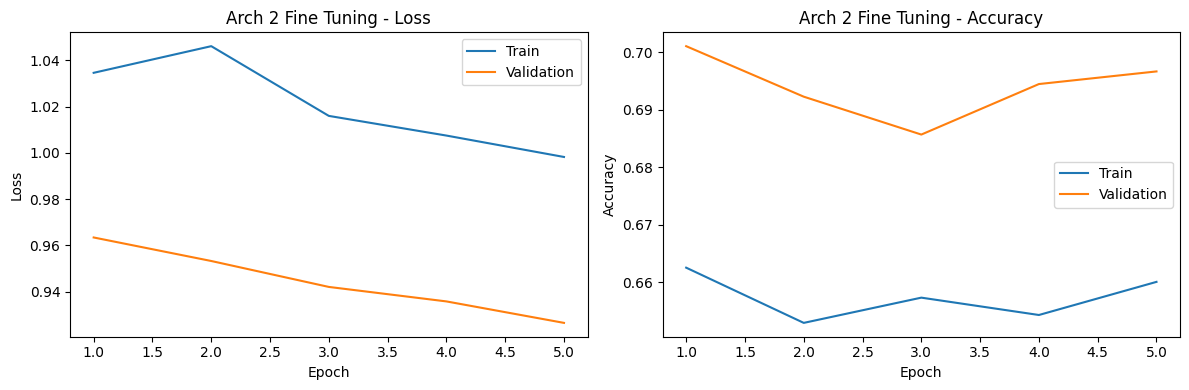

In [75]:
plot_learning_curves(res_arch2_ft, 'Arch 2 Fine Tuning')

### Architecture 3

Finally, the last pre-trained model we use is `EfficientNet B0`. This is the smallest variant of our first architecture. We will use this model because the second one showed us that performance in this problem isn't entirely dependent on model size, so we want to see if it really would make a different on the same model with lower parameter count.

Additionally, we will explore a new learning method **Gradual unfreezing**. It's the same thing we've done, except we train multiple times, each time with a different layer unfrozen.

https://www.shadecoder.com/ja/topics/gradual-unfreezing-a-comprehensive-guide-for-2025

Load the model.

In [76]:
arch3 = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.DEFAULT)
arch3 = arch3.to(device)

In [77]:
arch3

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [78]:
total_params = sum(p.numel() for p in arch3.parameters())
print(f"Params: {total_params:,}")

Params: 5,288,548


Then we add a classifier head. This time we will make it more complex, by making it a sequential module rather than just a linear layer. We will only use layers we saw in class `Dropout` and `Linear` (`ReLU`).

In [79]:
in_features_3 = arch3.classifier[1].in_features
arch3.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features_3, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, num_classes),
)
arch3 = arch3.to(device)

#### Transfer Learning

In transfer learning, we will freeze every layer except the head. 

Note that it is CONSIDERABLY smaller than both last models.

In [80]:
for param in arch3.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in arch3.parameters() if p.requires_grad)
total     = sum(p.numel() for p in arch3.parameters())
print(f"Trainable: {trainable:,} / {total:,}")

Trainable: 165,774 / 4,173,322


We reuse `CrossEntropyLoss` and `Adam` for only the classifier head we just made.

In [81]:
optimizer_tl_3 = torch.optim.Adam(arch3.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [82]:
res = train(arch3, train_loader_160, val_loader_160, criterion, optimizer_tl_3, _num_epochs=5)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 3/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 4/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 5/5:   0%|          | 0/65 [00:00<?, ?batch/s]

Final: train_loss: 1.2238  train_acc: 0.5977  val_loss: 1.1342  val_acc: 0.6308


Then we save.

In [83]:
res_arch3_tl = res
torch.save(arch3.state_dict(), 'arch3_tl.pth')

Then plot it.

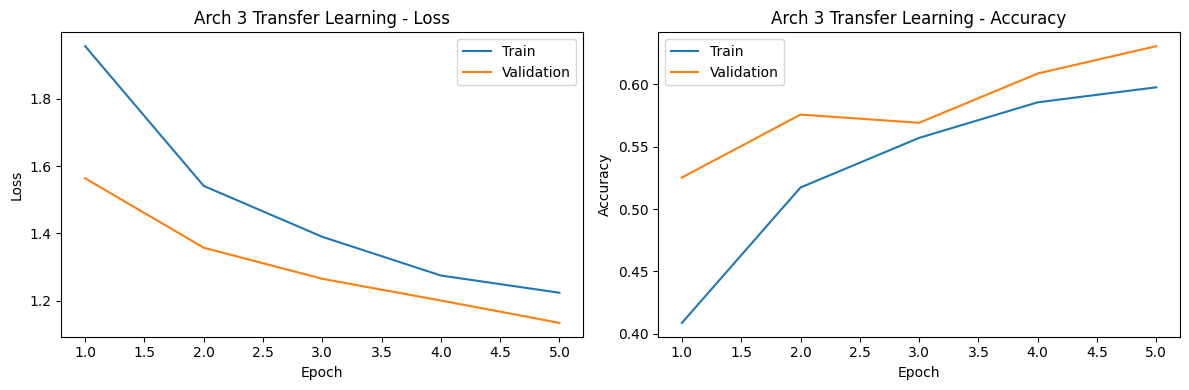

In [84]:
plot_learning_curves(res_arch3_tl, 'Arch 3 Transfer Learning')

The model performed *similarily* to the other models, but not quite the 75% that we had earlier.

#### Fine Tuning

In fine tuning, here is where we will use our gradual unfreezing of layers.

First we load the model.

In [85]:
arch3.load_state_dict(torch.load('arch3_tl.pth', map_location=device))

<All keys matched successfully>

In [86]:
arch3

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Then we freeze everything but the head.

In [87]:
for param in arch3.parameters():
    param.requires_grad = False
for param in arch3.classifier.parameters():
    param.requires_grad = True

And we will run this gradual unfreezing 3 times. 
- For every iteration, we copy-pasted the training process from above, except one extra layer is unfrozen.
- In the first iteration it's the last feature layer.
- In the second iteration it's the last 2 feature layers.
- In the third iteration it's the last 3 feature layers.

We will reuse `CrossEntropyLoss`.

`Adam` will optimize the classifier head with a bigger learning rate, while our unfrozen layers with a smaller one because otherwise training will take forever. This is the same reason we will be running only `2 epochs` per "run", so for 3 runs that will mean 6 epochs training.

In [88]:
features = list(arch3.features.children())
res_arch3_ft = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for run in range(1, 4):
    for param in features[-run].parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in arch3.parameters() if p.requires_grad)
    total = sum(p.numel() for p in arch3.parameters())
    print(f"\nRun {run}: {trainable:,} / {total:,} params")

    unfrozen = [p for p in arch3.features.parameters() if p.requires_grad]
    ft_opt_3 = torch.optim.Adam([
        {"params": unfrozen, "lr": 1e-5},
        {"params": list(arch3.classifier.parameters()), "lr": 1e-3},
    ])

    res = train(arch3, train_loader_160, val_loader_160, criterion, ft_opt_3, _num_epochs=2)

    # appends the results
    for k in res_arch3_ft:
        res_arch3_ft[k].extend(res[k])


Run 1: 577,934 / 4,173,322 params


Training:   0%|          | 0/2 [00:00<?, ?epoch/s]

Epoch 1/2:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 2/2:   0%|          | 0/65 [00:00<?, ?batch/s]

Final: train_loss: 1.1689  train_acc: 0.6153  val_loss: 1.0678  val_acc: 0.6484

Run 2: 1,295,166 / 4,173,322 params


...

Final: train_loss: 1.0802  train_acc: 0.6354  val_loss: 0.9876  val_acc: 0.6879

Run 3: 3,321,514 / 4,173,322 params


Training:   0%|          | 0/2 [00:00<?, ?epoch/s]

Epoch 1/2:   0%|          | 0/65 [00:00<?, ?batch/s]

Epoch 2/2:   0%|          | 0/65 [00:00<?, ?batch/s]

Final: train_loss: 1.0518  train_acc: 0.6406  val_loss: 0.9358  val_acc: 0.6989


Then we save it.

In [89]:
torch.save(arch3.state_dict(), 'arch3_ft.pth')

And plot it.

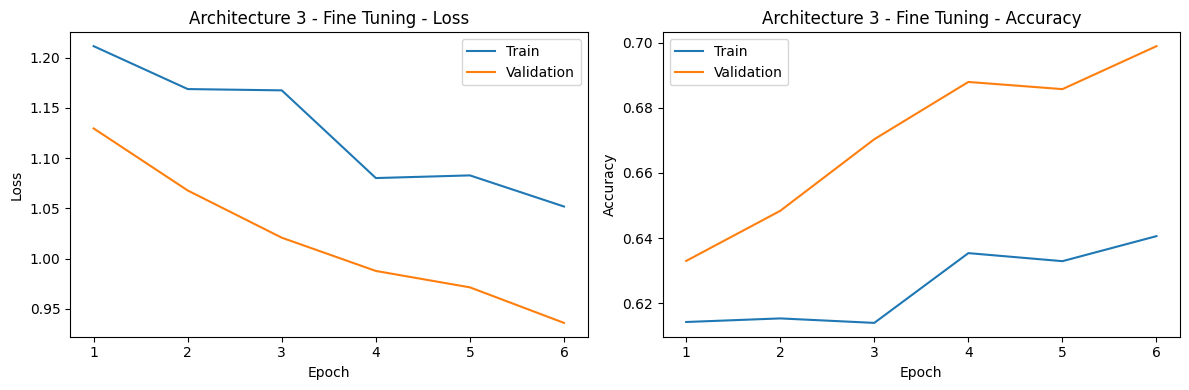

In [90]:
plot_learning_curves(res_arch3_ft, 'Architecture 3 - Fine Tuning')

The model improved a little.

## Evaluation

For evaluation, we will choose the models that have the least overfitting and best metrics (loss and accuracy).

First, let's use our overfitting function and map every model to its results. We will calculate a score for each model based on whether they are overfitting or not.

In [92]:
models = {
    "arch1_ft": {"val_acc": res_arch1_ft["val_acc"][-1], "train_acc": res_arch1_ft["train_acc"][-1],
                 "val_loss": res_arch1_ft["val_loss"][-1], "train_loss": res_arch1_ft["train_loss"][-1],
                 "model": arch1, "loader": test_loader, "res": res_arch1_ft},
    "arch2_ft": {"val_acc": res_arch2_ft["val_acc"][-1], "train_acc": res_arch2_ft["train_acc"][-1],
                 "val_loss": res_arch2_ft["val_loss"][-1], "train_loss": res_arch2_ft["train_loss"][-1],
                 "model": arch2, "loader": test_loader_160, "res": res_arch2_ft},
    "arch3_ft": {"val_acc": res_arch3_ft["val_acc"][-1], "train_acc": res_arch3_ft["train_acc"][-1],
                 "val_loss": res_arch3_ft["val_loss"][-1], "train_loss": res_arch3_ft["train_loss"][-1],
                 "model": arch3, "loader": test_loader_160, "res": res_arch3_ft},
}

score = {}
for k, v in models.items():
    loss_delta, acc_delta, overfitting = measure_overfitting(v["res"])
    if not overfitting:
        score[k] = v["val_acc"]
    else:
        score[k] = v["val_acc"] - acc_delta * 0.5 - loss_delta * 0.1
    print(f"{k}: val_acc={v['val_acc']:.4f}, train_acc={v['train_acc']:.4f}, val_loss={v['val_loss']:.4f}, train_loss={v['train_loss']:.4f}, overfitting={overfitting}")

Loss delta (val-train): -0.0806
Accuracy delta (train-val): -0.0696
No overfitting
arch1_ft: val_acc=0.7560, train_acc=0.6864, val_loss=0.8892, train_loss=0.9698, overfitting=False
Loss delta (val-train): -0.0717
Accuracy delta (train-val): -0.0366
No overfitting
arch2_ft: val_acc=0.6967, train_acc=0.6601, val_loss=0.9265, train_loss=0.9982, overfitting=False
Loss delta (val-train): -0.1160
Accuracy delta (train-val): -0.0583
No overfitting
arch3_ft: val_acc=0.6989, train_acc=0.6406, val_loss=0.9358, train_loss=1.0518, overfitting=False


In [93]:
score

{'arch1_ft': 0.7560439560439558,
 'arch2_ft': 0.6967032967032967,
 'arch3_ft': 0.6989010989010989}

Then, let's select the model with the highest score we calculated.

In [94]:
best_key = max(models, key=lambda k: score[k])
best_entry = models[best_key]
print(f"\nBest model: {best_key}")
print(f"Val Acc: {best_entry['val_acc']:.4f}")
print(f"Train Acc: {best_entry['train_acc']:.4f}")
print(f"Val Loss: {best_entry['val_loss']:.4f}")
print(f"Train Loss: {best_entry['train_loss']:.4f}")
print(f"Overfitting Score: {score[best_key]:.4f}")


Best model: arch1_ft
Val Acc: 0.7560
Train Acc: 0.6864
Val Loss: 0.8892
Train Loss: 0.9698
Overfitting Score: 0.7560


Finally, let's measure the model on the test set. To do this, we will retrieve its loader (each model had a different loader) and set the model to evaluation mode.

`best_loader` is the test set, defined above.

In [95]:
best_model = best_entry["model"]
best_loader = best_entry["loader"]
best_model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for X, y in best_loader:
        X = X.to(device)
        result = best_model(X)
        probs = torch.softmax(result, dim=1) # softmax because we want probabilities
        all_probs.append(probs.cpu().numpy()) # append
        all_preds.extend(result.argmax(dim=1).cpu().numpy()) # append
        all_labels.extend(y.numpy()) # append

# results
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.vstack(all_probs)

The accuracy score for the model is below:

In [96]:
test_acc = accuracy_score(all_labels, all_preds)

Then, to create the classification report we can use `sklearn`. Let's first map the categories to their indices and get their names, `sklearn` requires them for the table.

In [97]:
idx_to_cat = {v: k for k, v in cat_to_idx.items()}
class_names = [cat_ids[idx_to_cat[i]] for i in range(num_classes)]

print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=class_names, labels=range(num_classes)))

Test Accuracy: 0.7193

                            precision    recall  f1-score   support

                     empty       0.71      0.71      0.71       133
                    coyote       0.50      0.29      0.36         7
      reptile or amphibian       1.00      0.80      0.89        10
california ground squirrel       0.70      0.70      0.70        10
     western spotted skunk       1.00      0.68      0.81        34
            american robin       0.67      0.42      0.51        24
          leporidae family       0.75      0.81      0.78        93
              invertebrate       0.89      0.80      0.84        10
          northern raccoon       0.60      0.30      0.40        10
             striped skunk       0.25      0.10      0.14        10
              domestic dog       0.75      0.90      0.82        10
              small mammal       0.66      0.92      0.77        79
                  gray fox       0.62      0.50      0.56        10
                other bi

It's worth noting that the size of the dataset and volume of classes will leave some classes with lesser entries in some sets.

Let's also print out the results for the best model as a summary. We've already measured overfitting on the train vs validation set, but the instructions lead us to measure it against the test set too.

In [98]:
train_acc_final = best_entry["res"]["train_acc"][-1]
train_loss_final = best_entry["res"]["train_loss"][-1]
val_acc_final = best_entry["val_acc"]
print(f"Train acc : {train_acc_final:.4f}")
print(f"Val acc : {val_acc_final:.4f}")
print(f"Test acc : {test_acc:.4f}")
print(f"train-test delta: {train_acc_final - test_acc:.4f}")
if train_acc_final - test_acc > 0.1:
    print("Overfitting")
else:
    print("No overfitting")

Train acc : 0.6864
Val acc : 0.7560
Test acc : 0.7193
train-test delta: -0.0329
No overfitting


And finally, our confusion matrix. We use `sklearn` for it once again, with the labels and predictions that we made.

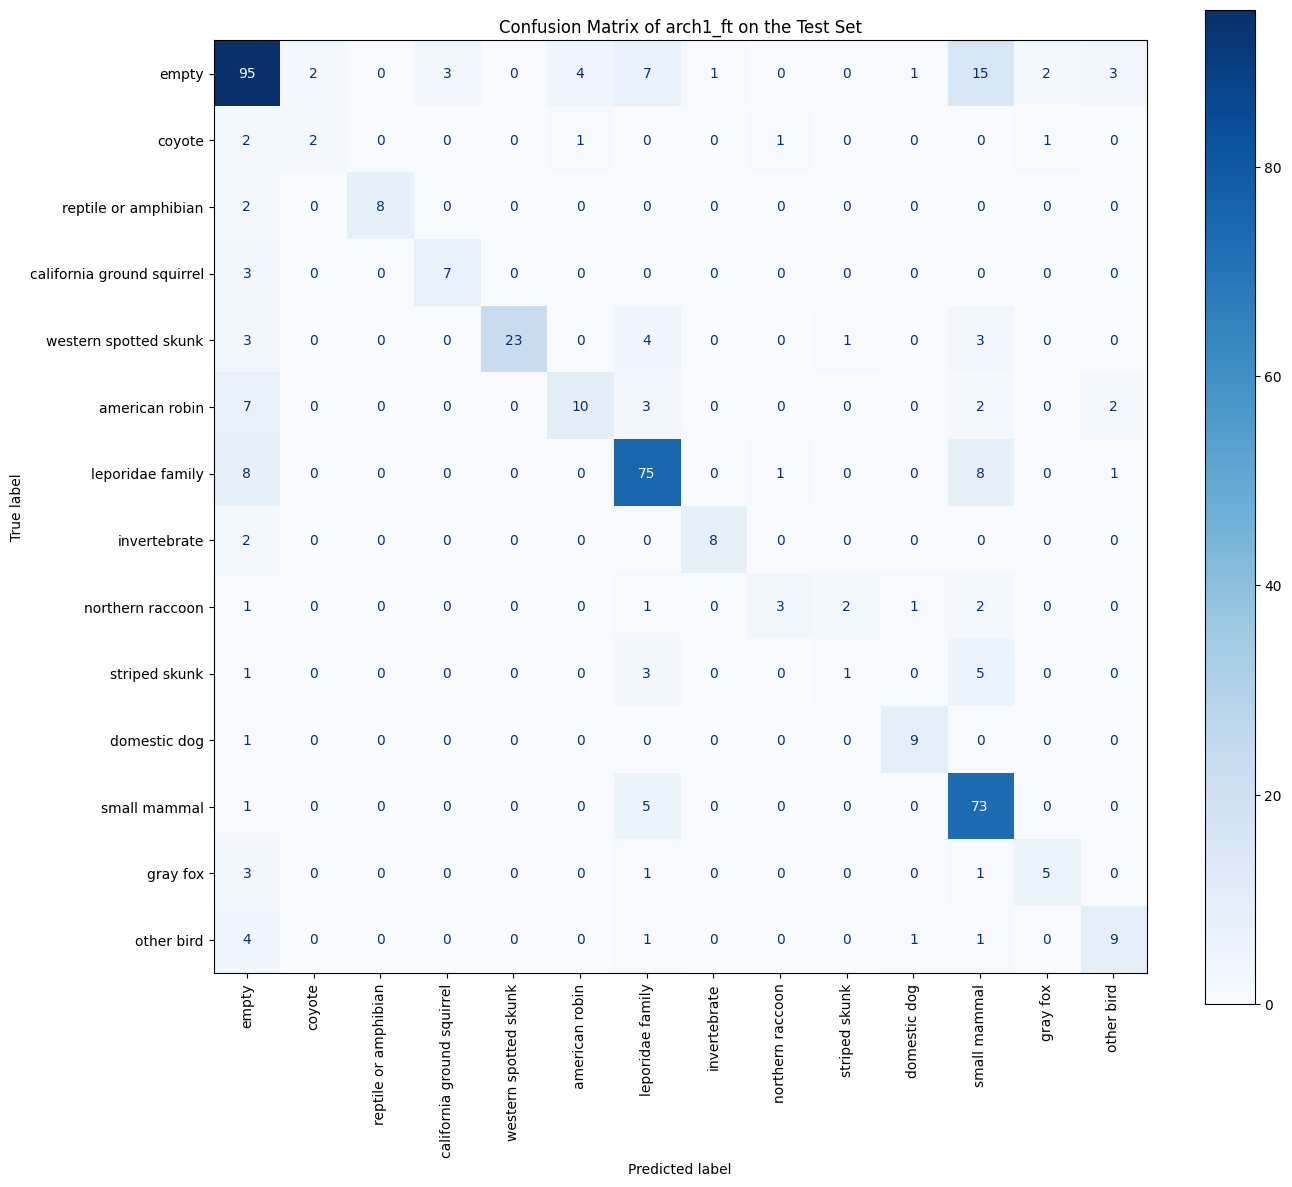

In [99]:
cm = confusion_matrix(all_labels, all_preds, labels=range(num_classes))
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=True, cmap="Blues")
ax.set_title(f"Confusion Matrix of {best_key} on the Test Set")
plt.tight_layout()
plt.show()

Here is the accuracy of the model per-class. To get the accuracy per class we can just divide the diagonals over the predictions made of that axis.

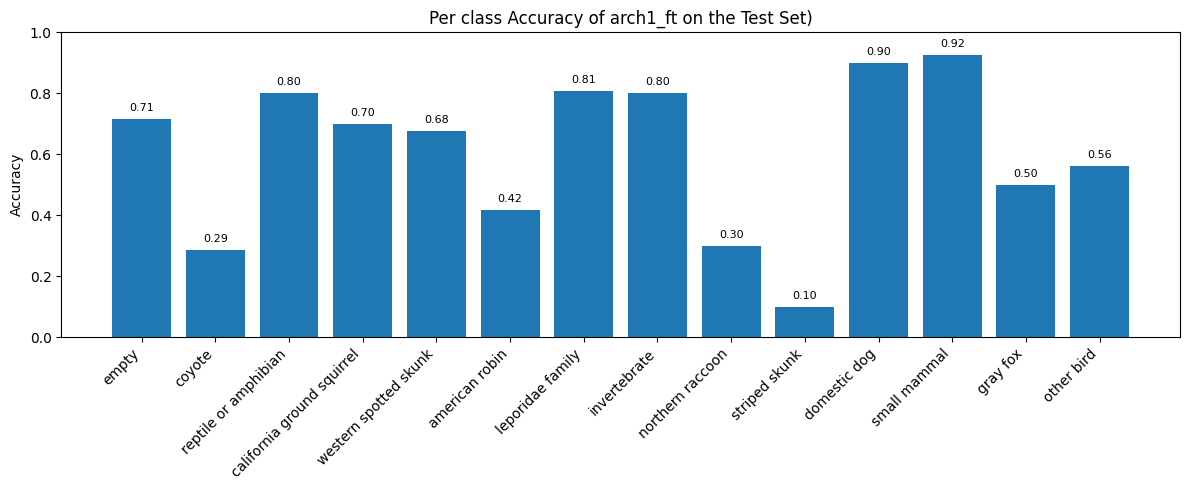

In [100]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_names, per_class_acc)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title(f"Per class Accuracy of {best_key} on the Test Set)")
plt.xticks(rotation=45, ha="right")
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

There's a fair bit of guessing (`~50`), but for the most part the model has decent accuracy (`>65`)

Finally, let's plot the loss and accuracy graph for this best model just as visualization, for train and validation. We will set the baseline of accuracy to the test accuracy for contrast.

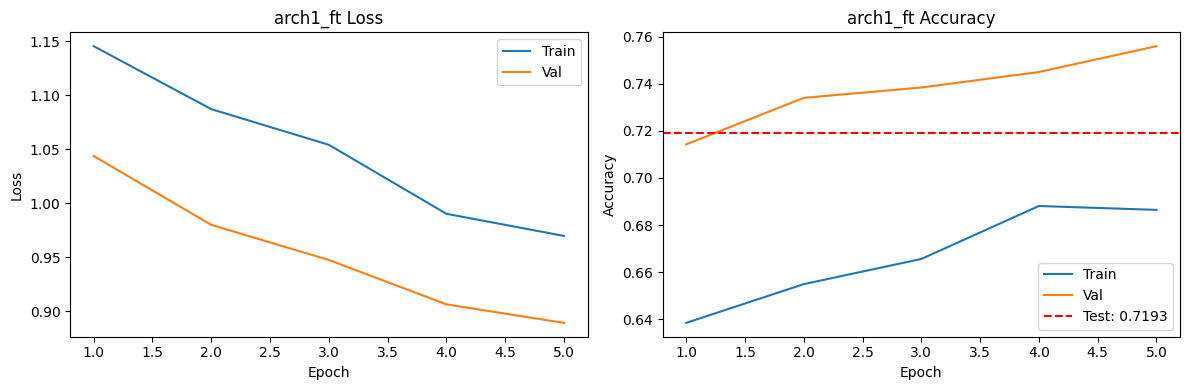

In [101]:
res_best = best_entry["res"]
epochs = range(1, len(res_best["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, res_best["train_loss"], label="Train")
ax1.plot(epochs, res_best["val_loss"],   label="Val")
ax1.set_title(f"{best_key} Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()

ax2.plot(epochs, res_best["train_acc"], label="Train")
ax2.plot(epochs, res_best["val_acc"],   label="Val")
ax2.axhline(y=test_acc, color="red", linestyle="--", label=f"Test: {test_acc:.4f}")
ax2.set_title(f"{best_key} Accuracy")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend()

plt.tight_layout()
plt.show()

## Serialization

Finally, we will need to serialize the model to use it in our prediction application. To do this, we can use ONNX with pytorch.

We need `sample_batch` and `dummy` because ONNX calculates the computation graph to serialize the model.

In [102]:
best_model.eval()
sample_batch, _ = next(iter(best_loader))
dummy = sample_batch[:1].to(device)

onnx_path = f"{best_key}.onnx"
torch.onnx.export(
    best_model, dummy, onnx_path,
    input_names=["input"], output_names=["logits"],
    dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=17,
)
print(f"Exported to {onnx_path}")

C:\Users\PC\AppData\Local\Temp\ipykernel_25244\4012528114.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0423 13:48:03.845000 25244 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\onnxscript\version_converter\__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\onnx\version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, t

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported to arch1_ft.onnx


Then let's verify it serialzied properly. We load the model into a session and run one inference with the dummy input we made. As long as the difference between the in-memory model and the loaded model is very small, we can assume it was exported properly.

In [103]:
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
ort_out = sess.run(["logits"], {"input": dummy.numpy()})[0]

with torch.no_grad():
    pt_out = best_model(dummy).numpy()

max_diff = abs(ort_out - pt_out).max()
print(f"Max output diff (PyTorch vs ONNX): {max_diff:.2e}")

Max output diff (PyTorch vs ONNX): 4.53e-06


Finally, we can test the model after it was validated.

Pick a random image from the test set

In [104]:
random_idx = random.randint(0, len(test_set) - 1)
img_tensor, true_label = test_set[random_idx]

Run the inference

In [105]:
input_arr = img_tensor.unsqueeze(0).numpy()
result = sess.run(["logits"], {"input": input_arr})[0]
pred_label = int(np.argmax(result))
confidence = float(torch.softmax(torch.tensor(result), dim=1).max())

And display it

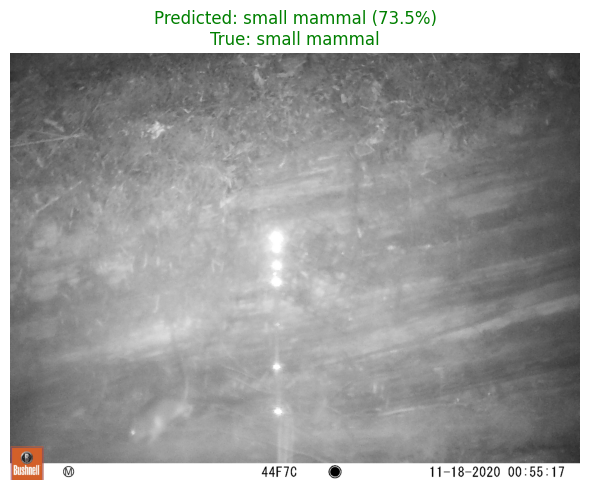

In [106]:
fname, _ = test_set.dataset.samples[test_set.indices[random_idx]]
img = Image.open(f"{out_dir}/{fname}").convert("RGB")

plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Predicted: {class_names[pred_label]} ({confidence:.1%})\n"
    f"True: {class_names[true_label]}",
    color="green" if pred_label == true_label else "red"
)
plt.tight_layout()
plt.show()

### Deserialization
To deserialize the model, you can start a session using
```py
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
```

Where `onnx_path` is the path to the onnx binaries. To make an inference: 
```py
input_arr = img_tensor.unsqueeze(0).numpy()
result = sess.run(["logits"], {"input": input_arr})[0]
pred_label = int(np.argmax(result))
confidence = float(torch.softmax(torch.tensor(result), dim=1).max())
```

## Final remarks

The following remarks can be made from the notebook at hand:
- Model size does not automatically guarantee better performance. We use three different training strategies (unfreezing one layer, unfreezing multiple, gradual unfreezing) on three distinct models with varying sizes, and they performed similarily to the best model.

- Gradual unfreezing is very good. Our models were performing poorly, but the more fine tuning we did, the better they appeared to perform.

- EDA is imperative. We needed to reduce the size of the set, so we had to do row and column selection to avoid including unnecessary data. Even still, we had to reduce the remaining dataset size by a factor to compute our models.

- It's very useful to print a model's architecture before transfer learning and fine tuning because it gives a good visualization and understanding of the model architecture, and allows the selection of layers to work with and exclude during the training process.

- Having a separate validation and training preprocessing pipeline *appeared* to be good. We are not fully aware of *how* good because we didn't run benchmarks, but it bumped our model accuracy a little bit for it to be significant

All in all, we are very satisfied with the training steps we took for our model as well as the EDA made. We understood the dataset properties fully (like footers, colors, channels, sizes) and how it influenced our training execution (time, because of size). Our model performance was satisfying enough, and we will use it in our application next.